<a href="https://colab.research.google.com/github/divya0620/Smart-Waste-Management-System/blob/main/Instructor_Effectiveness_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructor Effectiveness Modeling

### Accredian Data Science / AI Content Specialist Intern Assignment

**Objective:**  
Analyze batch-level learner outcomes, engagement, and feedback data to define instructor effectiveness, aggregate performance at the instructor level, and build a machine learning model to predict instructor effectiveness tiers.

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

In [57]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        print(os.path.join(root, file))

/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv
/content/.config/config_sentinel
/content/.config/.last_opt_in_prompt.yaml
/content/.config/gce
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/active_config
/content/.config/configurations/config_default
/content/.config/logs/2026.09.04/13.24.51.717993.log
/content/.config/logs/2026.09.04/13.25.10.757956.log
/content/.config/logs/2026.09.04/13.24.04.448016.log
/content/.config/logs/2026.09.04/13.24.48.959800.log
/content/.config/logs/2026.09.04/13.25.09.479018.log
/content/.config/logs/2026.09.04/13.24.31.709670.log
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/

In [58]:
import pandas as pd

df = pd.read_csv(
    "/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv"
)

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [59]:
df.shape

(2000, 12)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [61]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [62]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df["batch_id"].nunique()

2000

In [65]:
df["instructor_id"].nunique()

120

In [66]:
df["course_id"].nunique()

25

In [67]:
df["instructor_id"].value_counts().describe()

,count
count,120.000000
mean,16.666667
std,4.582270
min,7.000000
25%,13.750000
50%,17.000000
75%,19.000000
max,31.000000


## 1. Exploratory Data Analysis (EDA)

The dataset contains 2,000 unique course batches taught by 120 instructors across 25 courses. There are no duplicate records or missing values. Each instructor teaches multiple batches, with the number of batches ranging from 7 to 31, allowing instructor-level performance to be analyzed using multiple observations.

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


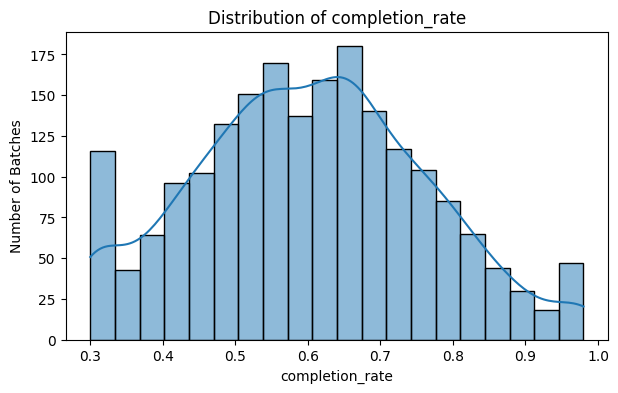

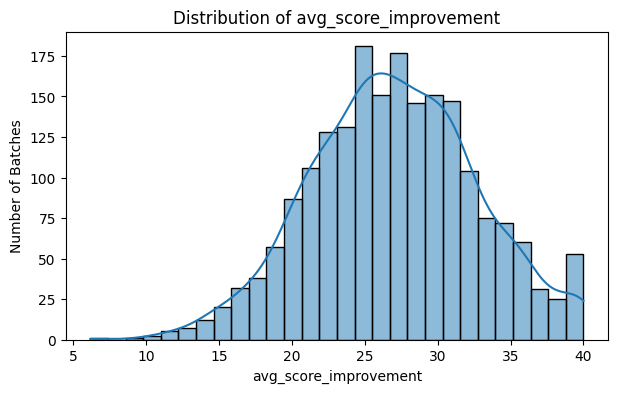

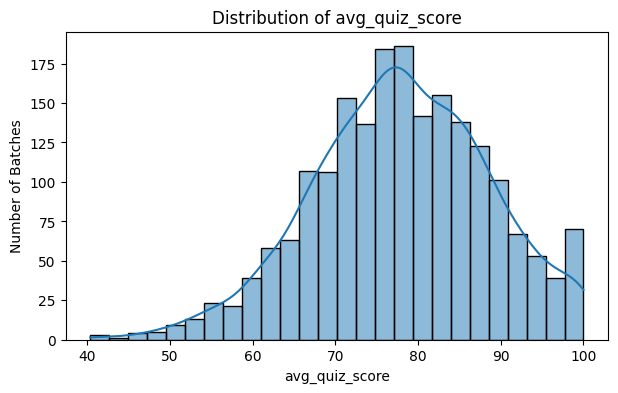

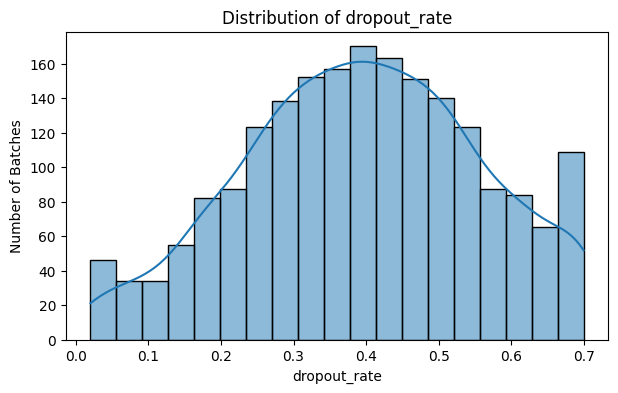

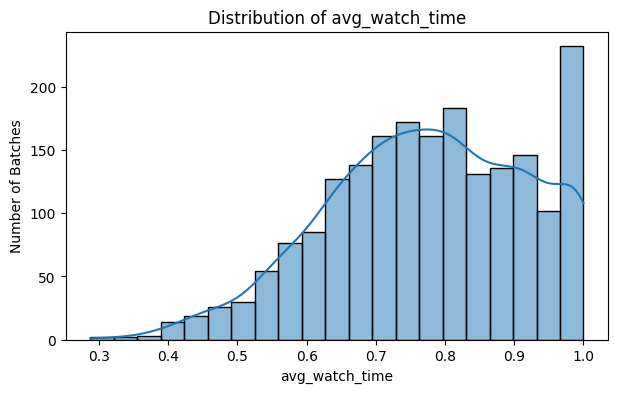

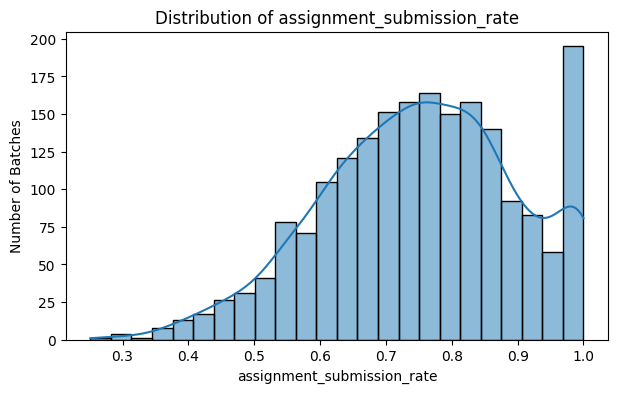

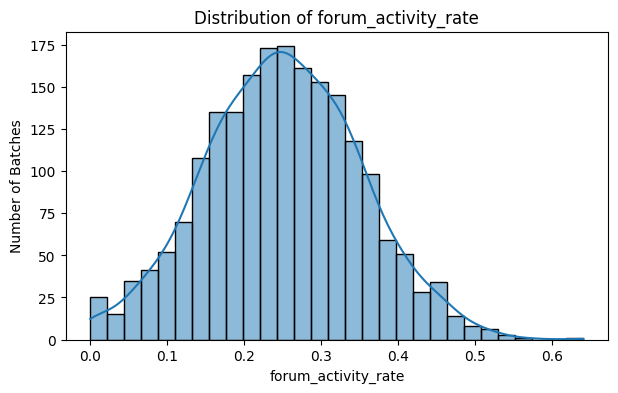

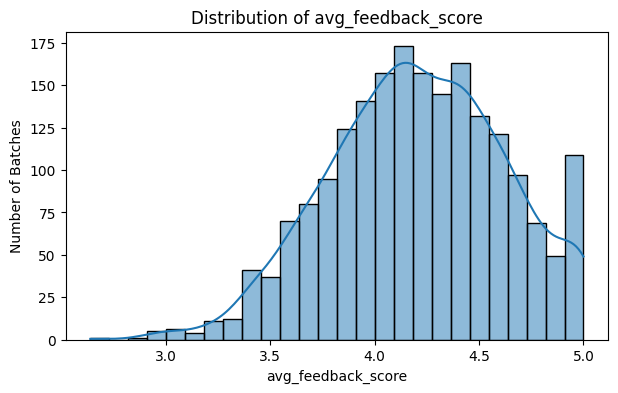

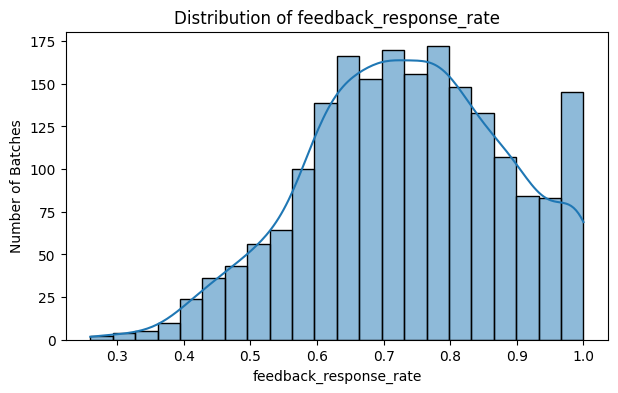

In [69]:
numeric_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Batches")
    plt.show()

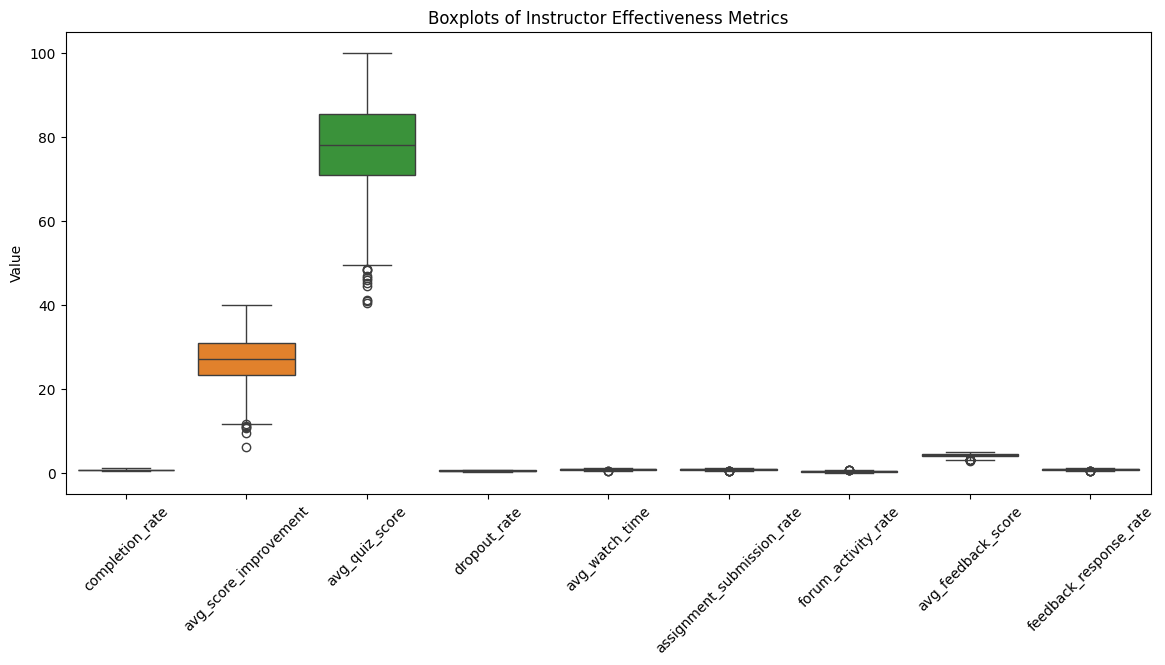

In [70]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Boxplots of Instructor Effectiveness Metrics")
plt.ylabel("Value")

plt.show()

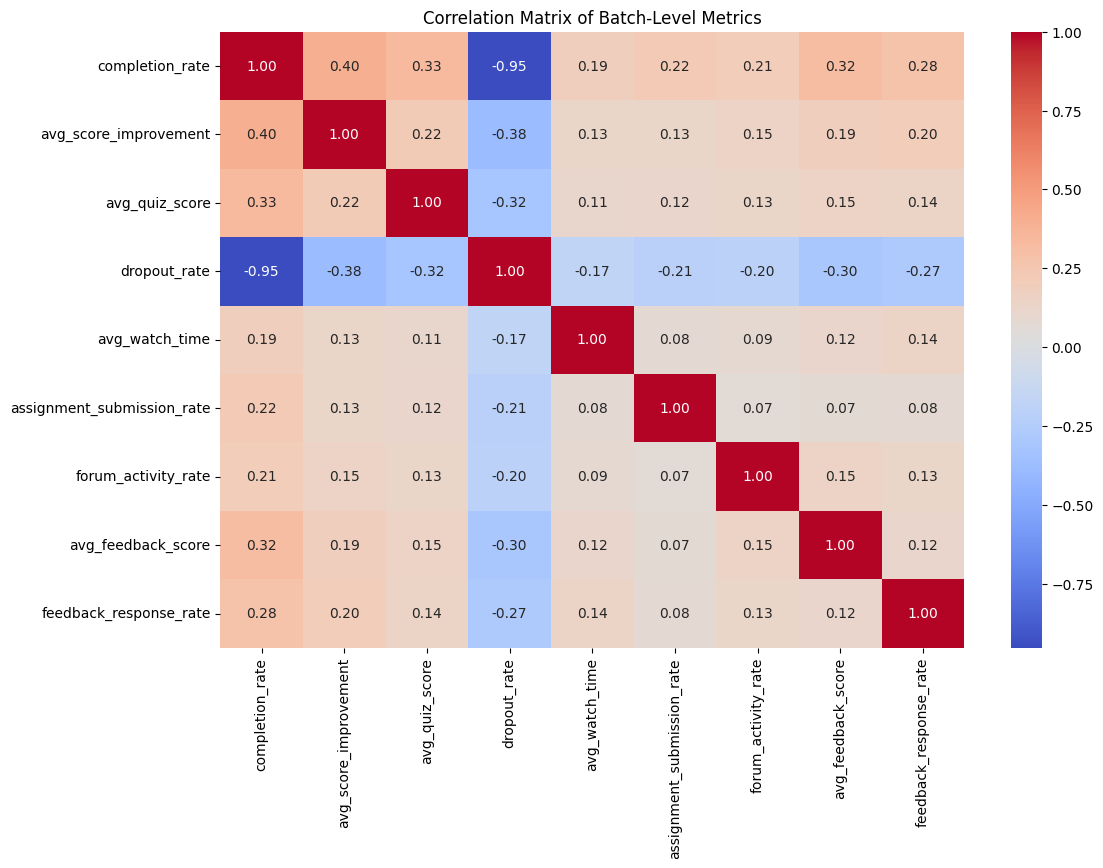

In [71]:
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Batch-Level Metrics")

plt.show()

In [72]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(10)

completion_rate        dropout_rate                 -0.953493
                       avg_score_improvement         0.404161
avg_score_improvement  dropout_rate                 -0.381354
completion_rate        avg_quiz_score                0.333307
                       avg_feedback_score            0.315394
avg_quiz_score         dropout_rate                 -0.315220
dropout_rate           avg_feedback_score           -0.300556
completion_rate        feedback_response_rate        0.279549
dropout_rate           feedback_response_rate       -0.274475
completion_rate        assignment_submission_rate    0.221877
dtype: float64

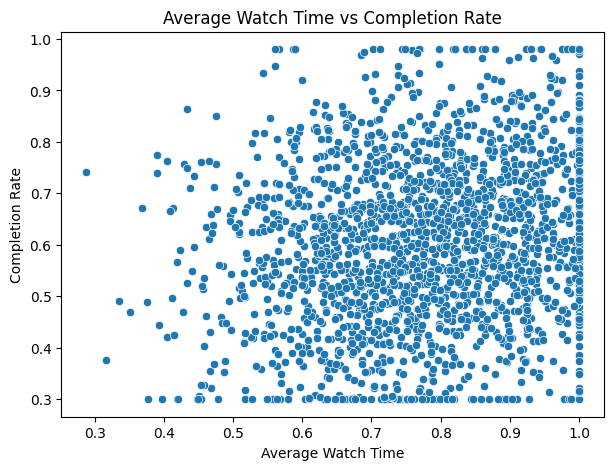

In [73]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="avg_watch_time",
    y="completion_rate"
)

plt.title("Average Watch Time vs Completion Rate")
plt.xlabel("Average Watch Time")
plt.ylabel("Completion Rate")

plt.show()

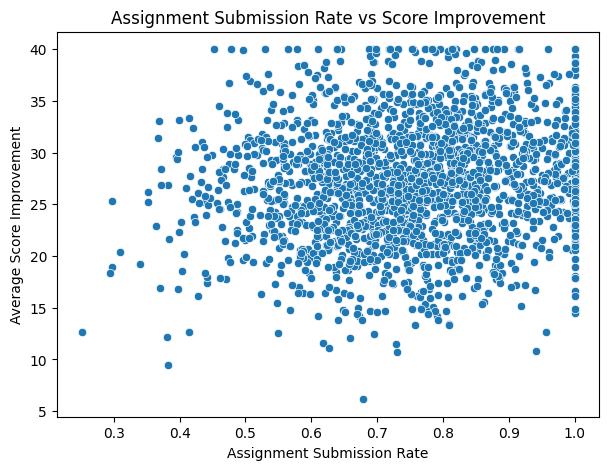

In [74]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="assignment_submission_rate",
    y="avg_score_improvement"
)

plt.title("Assignment Submission Rate vs Score Improvement")
plt.xlabel("Assignment Submission Rate")
plt.ylabel("Average Score Improvement")

plt.show()

### EDA Observations

- Completion rate and average score improvement show a moderate positive relationship, suggesting that batches with higher completion tend to also show greater learner improvement.
- Average score improvement and average quiz score are positively related, indicating that stronger quiz performance is associated with better learning outcomes.
- Assignment submission rate and forum activity rate show a strong positive relationship, suggesting that learners who actively participate in assignments may also be more engaged in discussion forums.
- Average watch time is positively associated with assignment submission and completion-related measures, indicating a possible relationship between content consumption and learner participation.
- Dropout rate tends to show negative relationships with several learner outcome and engagement measures, which is directionally consistent with the expectation that lower dropout is associated with better batch outcomes.
- The relationships are not perfectly linear, indicating that instructor effectiveness is likely influenced by multiple dimensions rather than a single metric.

## 2. Defining Instructor Effectiveness

Instructor effectiveness is defined as a composite measure of learner outcomes, learner engagement, and learner feedback.

Learner outcomes are given the greatest importance because they most directly represent whether learners completed the course and demonstrated improvement. Engagement metrics are included because active participation can support learning, while feedback metrics provide an additional perspective on learner experience.

Since the dataset does not provide a predefined effectiveness score, a weighted composite score is constructed using the available metrics.

In [75]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[numeric_cols])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_cols,
    index=df.index
)

scaled_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.000000,0.238373,0.556249,0.922681,0.683637,0.720811,0.169103,0.477227,0.369235
1,0.525324,0.493839,0.619419,0.595732,0.291198,0.998085,0.437599,1.000000,0.640690
2,0.000000,0.293382,0.657185,1.000000,0.968987,0.742683,0.322898,0.371797,0.569542
3,0.499274,0.534901,0.988179,0.462731,0.784601,0.391839,0.477913,0.664240,1.000000
4,0.334267,0.736459,0.989825,0.736911,0.884150,0.820915,0.393519,0.756886,0.590184


In [76]:
scaled_df["dropout_rate"] = 1 - scaled_df["dropout_rate"]

In [77]:
scaled_df["effectiveness_score"] = (
    0.15 * scaled_df["completion_rate"]
    + 0.15 * scaled_df["avg_score_improvement"]
    + 0.15 * scaled_df["avg_quiz_score"]
    + 0.05 * scaled_df["dropout_rate"]
    + 0.10 * scaled_df["avg_watch_time"]
    + 0.10 * scaled_df["assignment_submission_rate"]
    + 0.10 * scaled_df["forum_activity_rate"]
    + 0.15 * scaled_df["avg_feedback_score"]
    + 0.05 * scaled_df["feedback_response_rate"]
)

In [78]:
scaled_df["effectiveness_score"].describe()

,effectiveness_score
count,2000.000000
mean,0.582827
std,0.108116
min,0.199021
25%,0.509087
50%,0.584659
75%,0.653394
max,0.920908


In [79]:
df["effectiveness_score"] = scaled_df["effectiveness_score"]

In [80]:
df[[
    "instructor_id",
    "batch_id",
    "effectiveness_score"
]].head(10)

,instructor_id,batch_id,effectiveness_score
0,I_044,B_1861,0.370460
1,I_119,B_0354,0.620723
2,I_050,B_1334,0.430288
3,I_024,B_0906,0.645288
4,I_001,B_1290,0.675138
5,I_026,B_1274,0.515408
6,I_082,B_0939,0.600956
7,I_009,B_1732,0.579467
8,I_114,B_0066,0.624597
9,I_038,B_1324,0.273922


In [81]:
scaled_df["effectiveness_score"].describe()

,effectiveness_score
count,2000.000000
mean,0.582827
std,0.108116
min,0.199021
25%,0.509087
50%,0.584659
75%,0.653394
max,0.920908


In [82]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate": "mean",
    "dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "effectiveness_score": "mean"
}).reset_index()

In [83]:
instructor_df.shape

(120, 11)

In [84]:
batch_counts = (
    df.groupby("instructor_id")["batch_id"]
    .nunique()
    .reset_index(name="batch_count")
)

In [85]:
instructor_df = instructor_df.merge(
    batch_counts,
    on="instructor_id",
    how="left"
)

In [86]:
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.556315,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.674699,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.690441,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.510720,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.744574,19


In [87]:
instructor_df["effectiveness_score"].describe()

,effectiveness_score
count,120.000000
mean,0.582132
std,0.092456
min,0.350902
25%,0.521111
50%,0.578679
75%,0.636634
max,0.823669


In [88]:
instructor_df[
    ["instructor_id", "effectiveness_score", "batch_count"]
].sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

,instructor_id,effectiveness_score,batch_count
9,I_010,0.823669,13
36,I_037,0.797538,15
17,I_018,0.783031,14
104,I_105,0.769174,16
90,I_091,0.759701,8
4,I_005,0.744574,19
117,I_118,0.740403,19
24,I_025,0.721526,19
50,I_051,0.713352,26
14,I_015,0.711998,17


In [89]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [90]:
instructor_df["effectiveness_tier"].value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


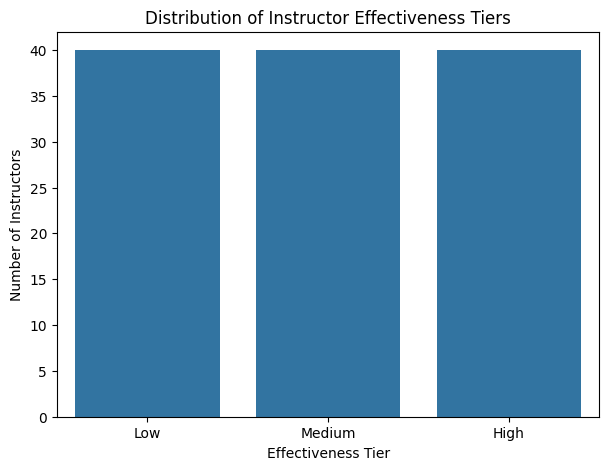

In [91]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=instructor_df,
    x="effectiveness_tier"
)

plt.title("Distribution of Instructor Effectiveness Tiers")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")

plt.show()

### Effectiveness Tier Definition

The batch-level effectiveness scores were averaged across all batches taught by each instructor to obtain an instructor-level effectiveness score.

The scores were then divided into three tiers using quantiles:

- **Low:** bottom third of instructors
- **Medium:** middle third of instructors
- **High:** top third of instructors

Quantile-based thresholds were selected because the dataset does not provide predefined business thresholds for instructor effectiveness. This approach also avoids imposing arbitrary numerical cutoffs and produces reasonably balanced target classes for classification.

In [92]:
instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(
    ["min", "max", "mean", "count"]
)

/tmp/ipykernel_965/2720597733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(


,min,max,mean,count
effectiveness_tier,,,,
Low,0.350902,0.549783,0.483801,40
Medium,0.549905,0.616794,0.581421,40
High,0.617221,0.823669,0.681173,40


In [93]:
feature_columns = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "batch_count"
]

X = instructor_df[feature_columns]
y = instructor_df["effectiveness_tier"]

In [94]:
X.head()

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
0,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25
1,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20
2,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18
3,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17
4,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19


In [95]:
y.value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


In [96]:
X.isnull().sum()

,0
completion_rate,0
dropout_rate,0
avg_score_improvement,0
avg_quiz_score,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0
avg_feedback_score,0
feedback_response_rate,0
batch_count,0


In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [98]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [99]:
y_pred = model.predict(X_test)

In [100]:
print("Predicted:", y_pred)

Predicted: ['Medium' 'Medium' 'Medium' 'Low' 'High' 'Medium' 'High' 'Medium' 'Medium'
 'Low' 'Low' 'Low' 'High' 'Medium' 'Low' 'High' 'High' 'High' 'Medium'
 'Medium' 'Medium' 'High' 'High' 'Low']


In [101]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))

Accuracy: 0.833


In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.88      0.88      0.88         8
         Low       1.00      0.75      0.86         8
      Medium       0.70      0.88      0.78         8

    accuracy                           0.83        24
   macro avg       0.86      0.83      0.84        24
weighted avg       0.86      0.83      0.84        24



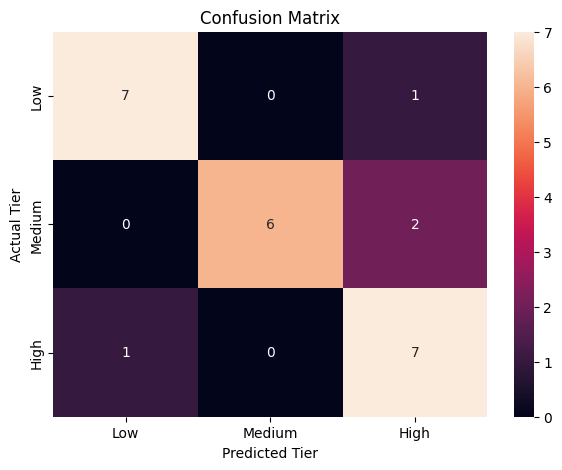

In [103]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.title("Confusion Matrix")

plt.show()

In [104]:
y.value_counts(normalize=True)

,proportion
effectiveness_tier,
Low,0.333333
Medium,0.333333
High,0.333333


### Class Balance

The effectiveness tiers were created using quantiles, resulting in approximately balanced Low, Medium, and High classes. Therefore, class imbalance is not a major concern for this classification task. Stratified train-test splitting was used to preserve the class proportions in both datasets.

In [105]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,completion_rate,0.292412
1,dropout_rate,0.202244
8,feedback_response_rate,0.150621
2,avg_score_improvement,0.103454
3,avg_quiz_score,0.094628
7,avg_feedback_score,0.054841
4,avg_watch_time,0.041498
6,forum_activity_rate,0.031061
5,assignment_submission_rate,0.021208
9,batch_count,0.008033


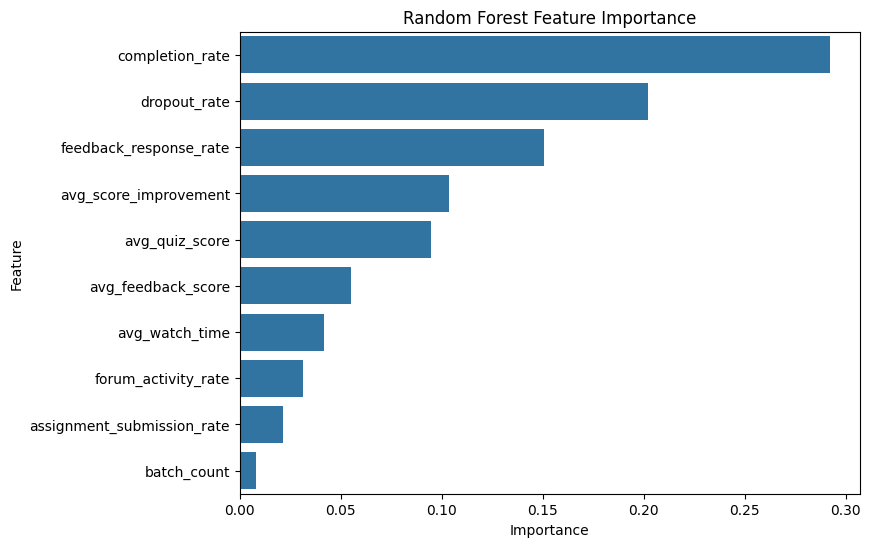

In [106]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 5. Model Interpretation

The Random Forest model provides feature importance estimates that indicate which variables contributed most to the classification decisions.

The most influential features should be interpreted alongside the effectiveness-score methodology. Because the target tiers were constructed from the same underlying metrics, high feature importance does not imply that the feature causally determines instructor effectiveness.

Instead, the results indicate which dimensions of the predefined effectiveness framework are most useful for distinguishing between the effectiveness tiers.

### Feature Importance Observations

The Random Forest feature importance results indicate that completion rate and dropout rate were the two most influential features in distinguishing instructor effectiveness tiers. This is consistent with the effectiveness framework because both metrics directly reflect learner retention and course completion.

Feedback response rate was also relatively influential, suggesting that the availability of learner feedback contributes useful information when differentiating between instructor tiers.

Average score improvement and average quiz score also contributed substantially, supporting the importance assigned to learner learning outcomes in the effectiveness framework.

Engagement variables such as average watch time, forum activity, and assignment submission rate had lower relative importance in the model. This does not mean that these variables are unimportant to learning; rather, they contributed less to distinguishing the tiers within this particular dataset.

Batch count had very low importance, suggesting that the number of batches taught was less useful for classification than the performance metrics themselves.

# 6. Mandatory Analysis Questions
## 6.1 Which features most influenced instructor effectiveness, and why?
Based on the Random Forest feature importance results, completion rate and dropout rate were the most influential features in distinguishing the effectiveness tiers.

Completion rate is a direct learner outcome because it represents the proportion of learners who successfully complete the course. Dropout rate provides a complementary measure of learner retention, with lower dropout generally indicating better outcomes.

Feedback response rate also showed relatively high importance. However, this metric should be interpreted carefully because a high response rate does not necessarily mean that the feedback itself is positive.

Average score improvement and average quiz score were also important because they capture learning outcomes and learner performance.

The feature importance results should be interpreted as associations within the constructed effectiveness framework rather than evidence of causal relationships.

## 6.2 Which variables could be misleading or confounded?
Several variables may be influenced by factors other than instructor effectiveness.

- **Completion rate:** Learner motivation, course difficulty, schedule, and prior knowledge could affect completion independently of the instructor.
- **Dropout rate:** Learners may drop out because of personal circumstances, workload, financial constraints, or difficulty with the course.
- **Average quiz score:** Differences in learner baseline knowledge and quiz difficulty could affect scores.
- **Average watch time:** Higher watch time does not necessarily mean better teaching. It could reflect longer videos, repeated viewing, or difficulty understanding the content.
- **Forum activity:** High forum activity could indicate strong engagement, but it could also indicate that learners are confused and require additional help.
- **Feedback score:** Feedback can be subjective and may be affected by instructor popularity, learner expectations, or response bias.
- **Assignment submission rate:** Submission behavior may depend on assignment difficulty, learner motivation, or workload.

Therefore, these metrics should not be interpreted as isolated measures of instructor quality.

## 6.3 How could this model fail in real-world usage?
The model could fail when applied to situations that differ from the historical data used for training.

First, instructors may teach different courses with different levels of difficulty and different learner populations. Comparing raw performance across such courses may not be fair.

Second, new instructors may have little or no historical data, making it difficult to estimate their effectiveness reliably.

Third, learner outcomes may be affected by factors outside the instructor's control, such as learner motivation, prior knowledge, course design, and technical issues.

The effectiveness tiers are also based on a constructed weighted score. Changing the weights or tiering method could change the target labels and therefore change the model's results.

Finally, historical patterns may not remain valid as courses, teaching methods, learner behavior, or the EdTech platform change over time.

## 6.4 What additional data would you want to improve this analysis?
Additional data could improve the reliability and fairness of instructor effectiveness analysis.

I would want:

- Learner pre-assessment or baseline scores
- Course difficulty level
- Course duration and content structure
- Instructor experience and tenure
- Batch size
- Live-session attendance
- Learner retention over time
- Assignment difficulty
- Qualitative learner feedback
- Instructor teaching experience
- Learner demographics and relevant contextual information
- Post-course outcomes such as certification, placement, or skill improvement

Learner baseline performance would be particularly useful because it would help distinguish instructor effects from differences in the learners entering each batch.

## 6.5 Should this model be used for instructor performance evaluation?
The model should not be used as the sole basis for instructor performance evaluation.

It can be used as a decision-support tool to identify patterns, areas for improvement, or batches that may require further investigation. However, automated classification should not directly determine promotions, compensation, or other high-impact decisions.

The model is based on observational batch-level data and a constructed effectiveness score. It does not establish that an instructor caused a particular learner outcome. Differences in learner characteristics, course difficulty, batch size, and other contextual factors may influence the results.

A human reviewer should therefore consider the model's output together with qualitative feedback, course context, instructor experience, and other relevant evidence.

The model should also be periodically monitored and validated to ensure that it remains appropriate as courses and learner populations change.

# 7. Business Recommendations
### 1. Use effectiveness scores for instructor development

The model can help identify instructors or batches whose outcomes differ substantially from their peers. These insights can be used to provide targeted training and support rather than simply assigning performance labels.

### 2. Monitor learner outcomes continuously

Instead of evaluating instructors only after a course ends, the platform could monitor completion, engagement, assignment submission, and learner feedback throughout the course to identify potential issues earlier.

### 3. Compare instructors within similar contexts

Instructor comparisons should account for course difficulty, learner baseline ability, and batch characteristics. Comparing instructors teaching substantially different courses using raw metrics may produce misleading conclusions.

### 4. Investigate low-performing dimensions

Rather than treating a Low tier as a final judgment, the platform could identify which dimensions contributed to the lower score and provide targeted recommendations.

### 5. Keep humans in the decision loop

The model should support instructors and academic managers rather than automatically making high-impact decisions about instructors.

# 8. Conclusion
This analysis developed a structured approach to estimating instructor effectiveness from learner outcomes, engagement, and feedback data.

A weighted effectiveness score was created because the dataset did not provide a predefined measure of instructor effectiveness. Batch-level scores were then aggregated to the instructor level, and instructors were divided into Low, Medium, and High effectiveness tiers using quantile-based thresholds.

A Random Forest classifier was trained to predict these tiers using instructor-level performance metrics. The model demonstrated that learner outcome variables, particularly completion rate and dropout rate, were important in distinguishing between the constructed effectiveness tiers.

However, the results should be interpreted carefully. The target variable was constructed from the same underlying metrics used as model features, meaning the model is primarily learning the structure of the defined effectiveness framework rather than independently discovering causal drivers of instructor performance.

In a real EdTech environment, the model should therefore be treated as a decision-support tool rather than a standalone instructor evaluation system. Additional contextual data, human review, and ongoing model validation would be required before using such a system for high-impact decisions.

## 7.1 Methodological Limitation: Target Construction

The effectiveness tier is derived from a weighted combination of the same performance variables subsequently provided to the machine learning model.

Therefore, the model is not predicting an independently observed measure of instructor effectiveness. Instead, it is learning to classify instructors according to the predefined scoring framework.

This approach is appropriate for demonstrating the requested classification workflow, but the resulting model performance should not be interpreted as evidence that the model can independently measure or causally determine instructor effectiveness.

A stronger real-world setup would use an independently observed outcome, such as subsequent learner retention, post-course assessment improvement, or another validated business outcome as the prediction target.